<a href="https://colab.research.google.com/github/aayushigupta098/Weather-Predictor-using-decision-trees/blob/main/Weather_Predictor_(ML)_by_Aayushi_Gupta.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

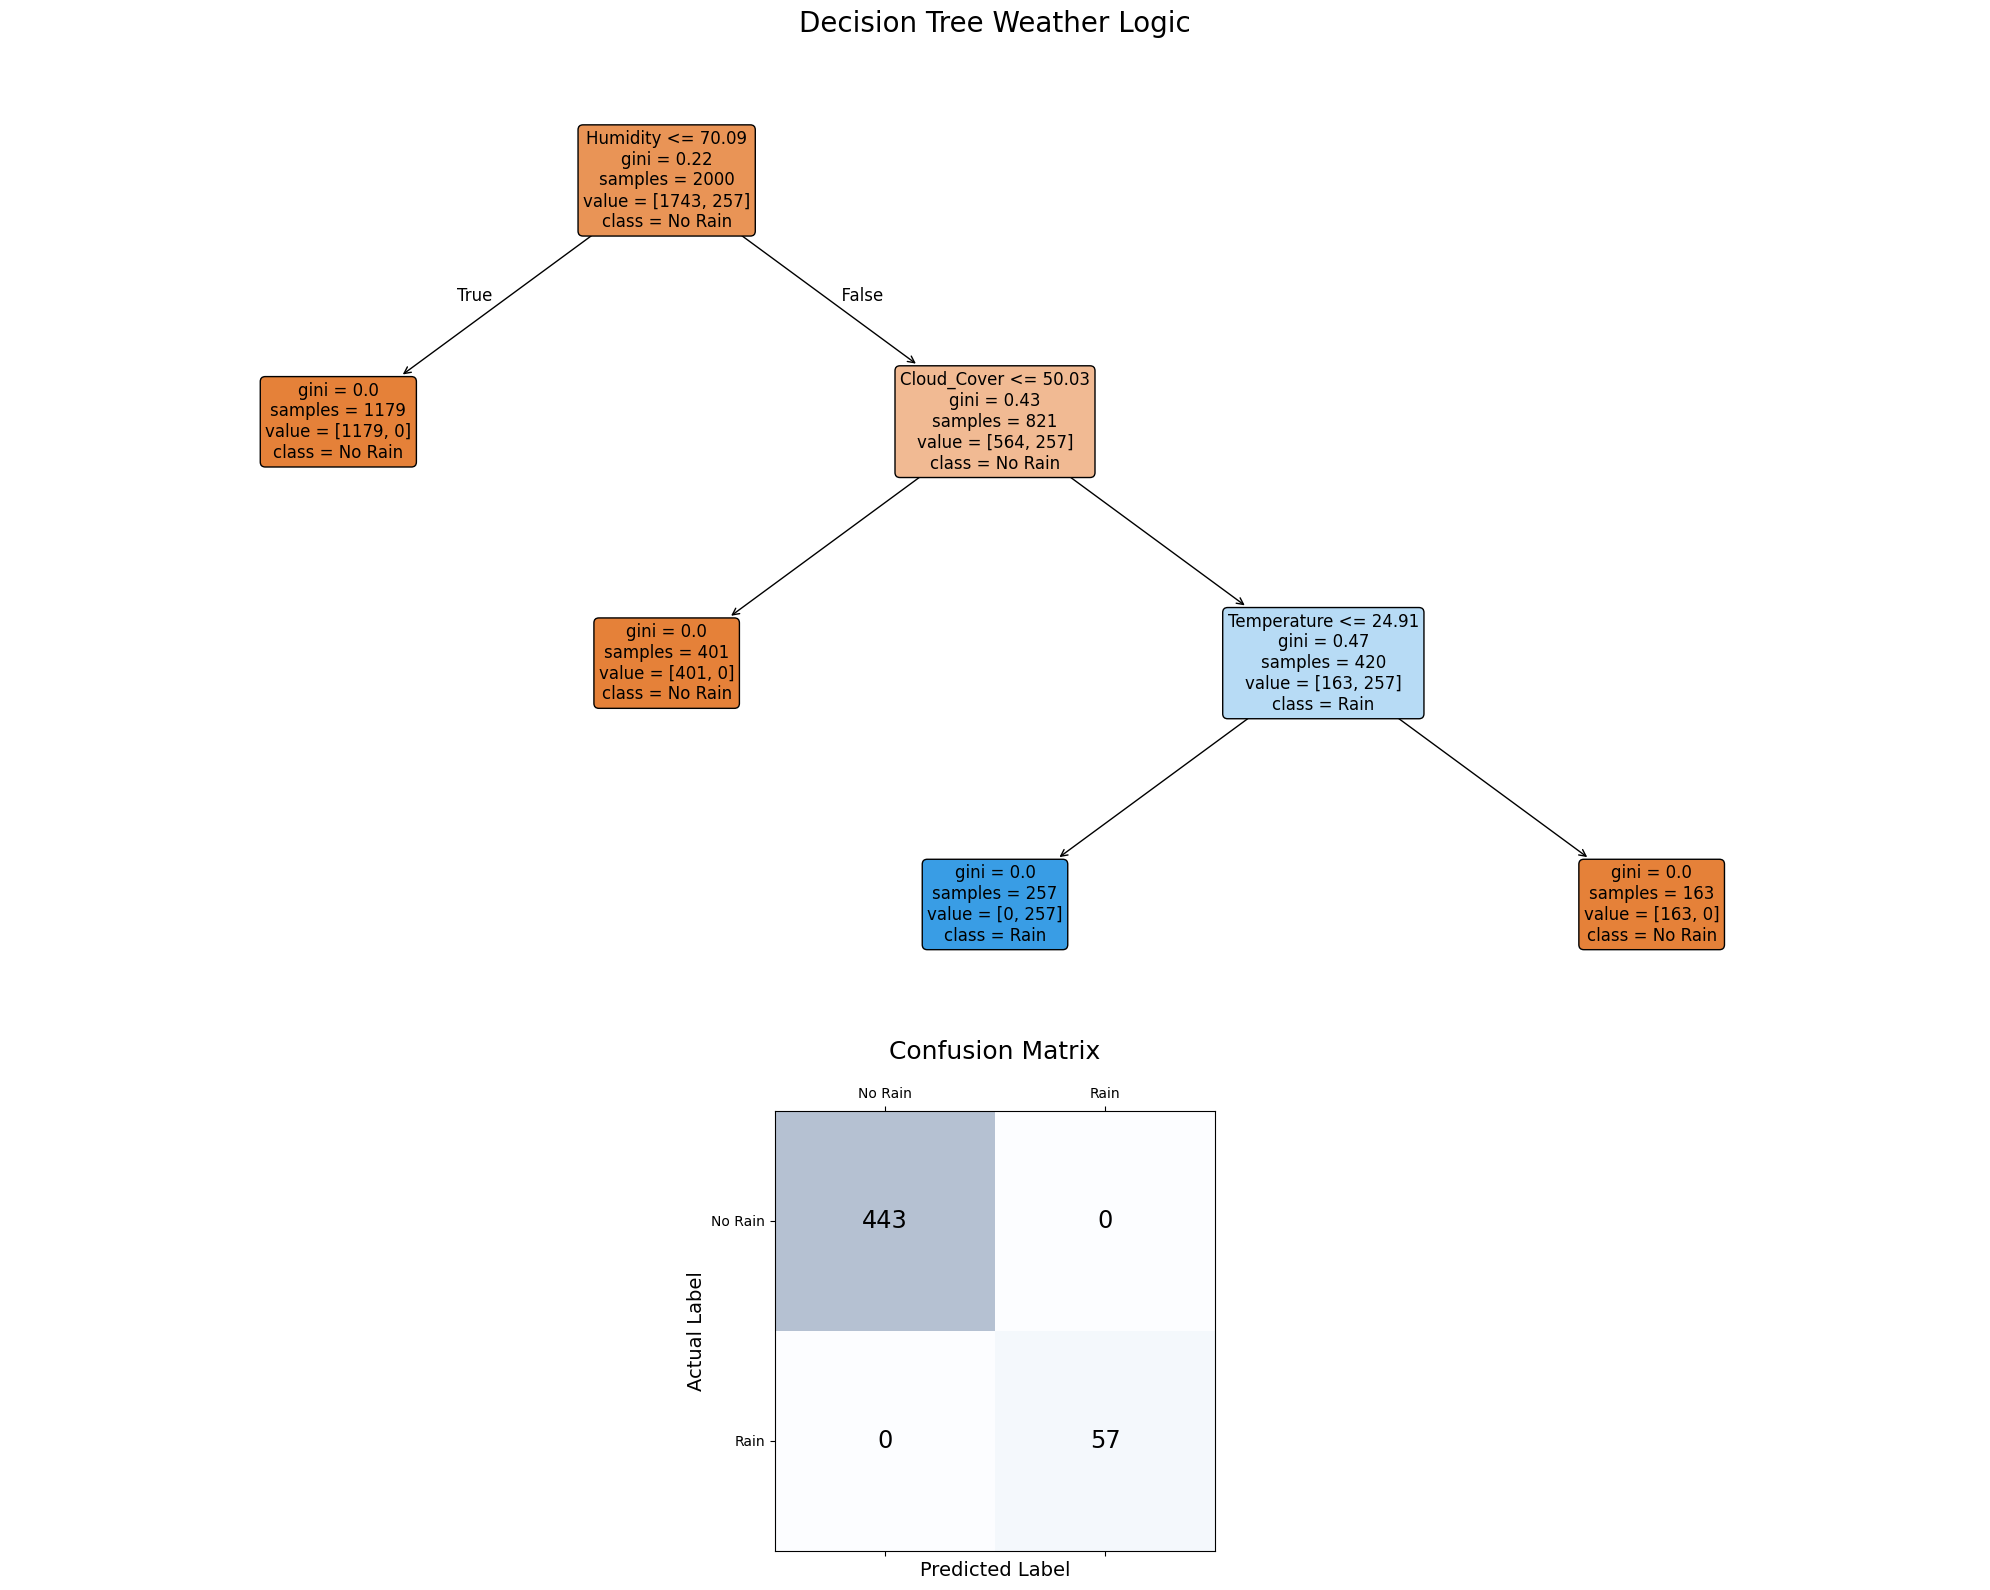

Project Accuracy: 100.00%


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import confusion_matrix, accuracy_score

# 1. Load and Prepare Data
df = pd.read_csv('weather_forecast_data.csv')
df['Rain'] = df['Rain'].map({'no rain': 0, 'rain': 1}) # Encoding target

X = df.drop('Rain', axis=1) # Features
y = df['Rain']              # Target

# 2. Split Data (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Train Model
# Max_depth=3 keeps the tree clear and readable
model = DecisionTreeClassifier(max_depth=3, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# 4. Create the Combined Visualization
# We create a large figure and split it into sections
fig = plt.figure(figsize=(20, 16))

# --- Top Section: Decision Tree ---
ax1 = plt.subplot2grid((3, 1), (0, 0), rowspan=2) # Occupies 2/3 of the height
plot_tree(model,
          feature_names=list(X.columns),
          class_names=['No Rain', 'Rain'],
          filled=True,
          rounded=True,
          fontsize=12,
          precision=2,
          ax=ax1)
ax1.set_title("Decision Tree Weather Logic", fontsize=20, pad=20)

# --- Bottom Section: Confusion Matrix ---
ax2 = plt.subplot2grid((3, 1), (2, 0)) # Occupies the bottom 1/3
cm = confusion_matrix(y_test, y_pred)

# Display the matrix as a colored grid
ax2.matshow(cm, cmap=plt.cm.Blues, alpha=0.3)

# Add the numbers inside the grid boxes
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax2.text(x=j, y=i, s=cm[i, j], va='center', ha='center', size='xx-large')

# Formatting the Confusion Matrix
ax2.set_xlabel('Predicted Label', fontsize=14)
ax2.set_ylabel('Actual Label', fontsize=14)
ax2.set_xticks([0, 1])
ax2.set_yticks([0, 1])
ax2.set_xticklabels(['No Rain', 'Rain'])
ax2.set_yticklabels(['No Rain', 'Rain'])
ax2.set_title('Confusion Matrix', fontsize=18, pad=20)

# Final output
plt.tight_layout()
plt.show()

# Print text results to console
print(f"Project Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")